In [4]:
import pandas as pd

In [5]:
import numpy as np

In [5]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'
!curl -O $data


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  7 1440k    7  112k    0     0  98885      0  0:00:14  0:00:01  0:00:13 99026
 84 1440k   84 1214k    0     0   555k      0  0:00:02  0:00:02 --:--:--  555k
100 1440k  100 1440k    0     0   601k      0  0:00:02  0:00:02 --:--:--  601k


In [6]:
df=pd.read_csv('data.csv')

In [7]:
df.columns=df.columns.str.lower().str.replace(' ','_')

In [8]:
df.dtypes

make                  object
model                 object
year                   int64
engine_fuel_type      object
engine_hp            float64
engine_cylinders     float64
transmission_type     object
driven_wheels         object
number_of_doors      float64
market_category       object
vehicle_size          object
vehicle_style         object
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [9]:
strings = list(df.dtypes[df.dtypes == 'object'].index)
strings
df['make']

0            BMW
1            BMW
2            BMW
3            BMW
4            BMW
          ...   
11909      Acura
11910      Acura
11911      Acura
11912      Acura
11913    Lincoln
Name: make, Length: 11914, dtype: object

In [10]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [11]:
df['make']

0            bmw
1            bmw
2            bmw
3            bmw
4            bmw
          ...   
11909      acura
11910      acura
11911      acura
11912      acura
11913    lincoln
Name: make, Length: 11914, dtype: object

In [12]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()
    

make
['bmw' 'audi' 'fiat' 'mercedes-benz' 'chrysler']
48

model
['1_series_m' '1_series' '100' '124_spider' '190-class']
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
['premium_unleaded_(required)' 'regular_unleaded'
 'premium_unleaded_(recommended)' 'flex-fuel_(unleaded/e85)' 'diesel']
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
['manual' 'automatic' 'automated_manual' 'direct_drive' 'unknown']
5

driven_wheels
['rear_wheel_drive' 'front_wheel_drive' 'all_wheel_drive'
 'four_wheel_drive']
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
['factory_tuner,luxury,high-performance' 'luxury,performance'
 'luxury,high-performance' 'luxury' 'performance']
71

vehicle_size
['compact' 'midsize' 'large']
3

vehicle_style
['coupe' 'convertible' 'sedan' 'wagon' '4dr_hatchback']
16

highway_mpg
[26 28 27 25 24]
59

city_mpg
[19 20 18 17 16]
69

popularity
[3916 3105  819  617 1013]
48

msrp
[46135 40650 36350 29450 345

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

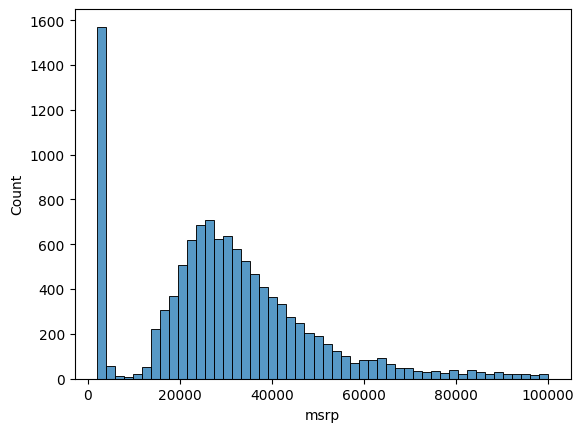

In [14]:
sns.histplot(df.msrp[df.msrp <=100000], bins=50)


In [15]:
price_logs = np.log1p(df.msrp)



<Axes: xlabel='msrp', ylabel='Count'>

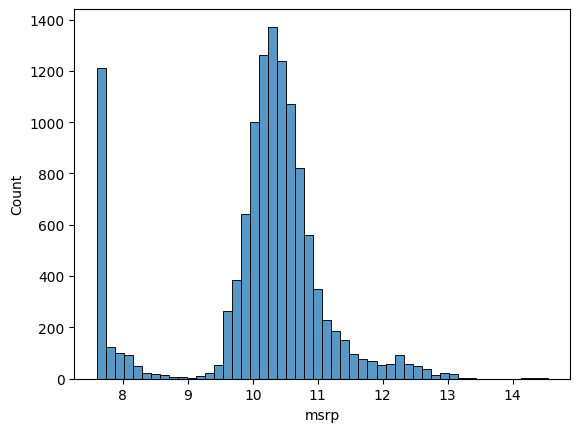

In [16]:
sns.histplot(price_logs, bins=50)


In [17]:
df.isnull().sum()


make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

In [18]:
## SET UP FOR MODEL

In [19]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [20]:
df_train = df.iloc[:n_train]
df_val = df.iloc[n_train:n_train+n_val]
df_test = df.iloc[n_train+n_val:]

In [21]:
idx = np.arange(n)

In [22]:
np.random.seed(3)
np.random.shuffle(idx)

In [23]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [24]:
df_train.head()


,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
8929,volvo,s70,2000,regular_unleaded,190.0,5.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,24,17,870,2500
8806,gmc,s-15,1990,regular_unleaded,105.0,4.0,manual,rear_wheel_drive,2.0,NaN,compact,extended_cab_pickup,25,21,549,2000
7233,oldsmobile,ninety-eight,1995,regular_unleaded,225.0,6.0,automatic,front_wheel_drive,4.0,NaN,large,sedan,26,17,26,2000
3535,aston_martin,dbs,2010,premium_unleaded_(required),510.0,12.0,automatic,rear_wheel_drive,2.0,"exotic,high-performance",midsize,convertible,18,12,259,283900
8763,chevrolet,s-10,2002,regular_unleaded,190.0,6.0,automatic,rear_wheel_drive,2.0,performance,compact,regular_cab_pickup,20,15,1385,21499


In [25]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [26]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [27]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

In [28]:
df_train.iloc[10]

make                            toyota
model                           sienna
year                              2016
engine_fuel_type      regular_unleaded
engine_hp                        266.0
engine_cylinders                   6.0
transmission_type            automatic
driven_wheels          all_wheel_drive
number_of_doors                    4.0
market_category                    NaN
vehicle_size                     large
vehicle_style        passenger_minivan
highway_mpg                         23
city_mpg                            16
popularity                        2031
Name: 10, dtype: object

In [29]:
xi = [266, 16, 2031]
w0 = 7.17
w = [0.01, 0.04, 0.002]
def linear_regression(xi):
    n = len(xi)

    pred = w0

    for j in range(n):
        pred = pred + w[j] * xi[j]

    return pred

In [30]:
linear_regression(xi)


14.532

In [31]:
np.expm1(14.532)


np.float64(2047232.6484084243)

In [32]:
## Linear vector form

In [33]:
def linear_regression(xi):
    return w0 + np.dot(xi, w)

In [34]:
w_new = [w0] + w


In [35]:
def linear_regression(xi):
    xi = [1] + xi
    return np.dot(xi, w_new)

In [36]:
linear_regression(xi)


np.float64(14.532)

In [37]:
x1  = [1, 148, 24, 1385]
x2  = [1, 132, 25, 2031]
x10 = [1, 453, 11, 86]

X = [x1, x2, x10]
X = np.array(X)
X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [40]:
def linear_regression(X):
    return np.dot(X,w_new)

In [41]:
linear_regression(X)


array([12.38 , 13.552, 12.312])

In [42]:
## TRAINING

In [61]:
X=  [  [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
]

X = np.array(X)

In [46]:
ones = np.ones(X.shape[0])


In [56]:
X = np.column_stack([ones, X])
X

array([[1.000e+00, 1.000e+00, 1.480e+02, 2.400e+01, 1.385e+03],
       [1.000e+00, 1.000e+00, 1.320e+02, 2.500e+01, 2.031e+03],
       [1.000e+00, 1.000e+00, 4.530e+02, 1.100e+01, 8.600e+01],
       [1.000e+00, 1.000e+00, 1.580e+02, 2.400e+01, 1.850e+02],
       [1.000e+00, 1.000e+00, 1.720e+02, 2.500e+01, 2.010e+02],
       [1.000e+00, 1.000e+00, 4.130e+02, 1.100e+01, 8.600e+01],
       [1.000e+00, 1.000e+00, 3.800e+01, 5.400e+01, 1.850e+02],
       [1.000e+00, 1.000e+00, 1.420e+02, 2.500e+01, 4.310e+02],
       [1.000e+00, 1.000e+00, 4.530e+02, 3.100e+01, 8.600e+01]])

In [48]:
y = [10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000]


In [49]:
XTX = np.dot(X.T,X)
XTX_inv = np.linalg.inv(XTX)
w_full = np.dot(np.dot(XTX_inv,X.T),y)

In [50]:
w0 = w_full[0]
w = w_full[1:]

In [51]:
w0

np.float64(25844.754055766833)

In [52]:
w

array([ -16.08906468, -199.47254894,   -1.22802883])

In [62]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = np.dot(X.T,X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = np.dot(np.dot(XTX_inv,X.T),y)
    return w_full[0], w_full[1:]

In [63]:
train_linear_regression(X, y)


(np.float64(25844.754055766833),
 array([ -16.08906468, -199.47254894,   -1.22802883]))

In [64]:
#baseline model

In [65]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg',
        'city_mpg', 'popularity']

X_train = df_train[base].fillna(0).values

w0, w = train_linear_regression(X_train, y_train)

y_pred = w0 + np.dot(X_train,w)

<Axes: ylabel='Count'>

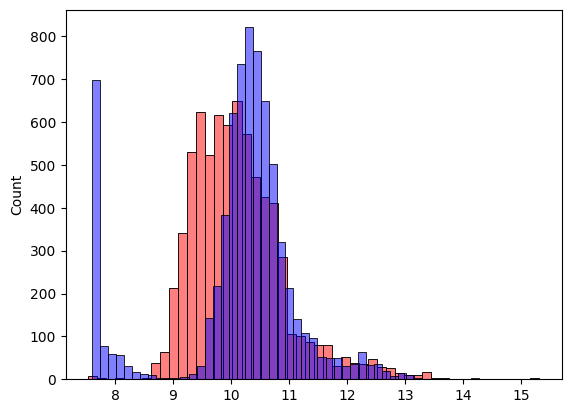

In [66]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

In [67]:
##RMSE

In [68]:
def rmse(y, y_pred):
    return np.sqrt(np.mean((y - y_pred) ** 2))


In [69]:
rmse(y_train, y_pred)


np.float64(0.7530702635167187)

In [70]:
## Validating the model

In [71]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X


In [73]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + np.dot(X_val,w)
rmse(y_val, y_pred)

np.float64(0.7460612947996899)

In [74]:
## Feature

In [75]:
def prepare_X(df):
    df = df.copy()
    
    df['age'] = 2025 - df['year']
    features = base + ['age']
    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [76]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.512385164444266)

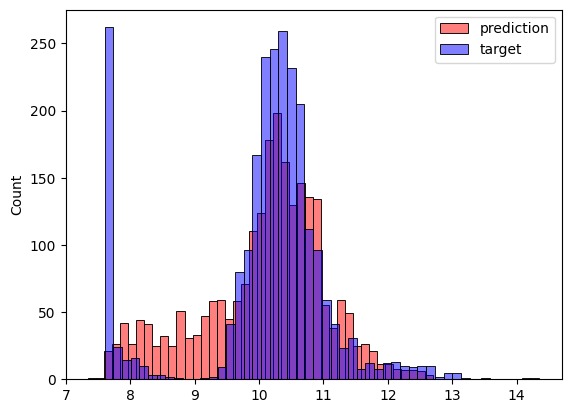

In [77]:
sns.histplot(y_pred, label='prediction', color='red', alpha=0.5, bins=50)
sns.histplot(y_val, label='target', color='blue',  alpha=0.5, bins=50)
plt.legend()

In [81]:
categorical_columns = [
    'make', 'model', 'engine_fuel_type', 'driven_wheels', 'market_category',
    'vehicle_size', 'vehicle_style']

categorical = {}

for c in categorical_columns:
    categorical[c] = list(df_train[c].value_counts().head().index)
categorical

{'make': ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'],
 'model': ['silverado_1500',
  'tundra',
  'f-150',
  'sierra_1500',
  'beetle_convertible'],
 'engine_fuel_type': ['regular_unleaded',
  'premium_unleaded_(required)',
  'premium_unleaded_(recommended)',
  'flex-fuel_(unleaded/e85)',
  'diesel'],
 'driven_wheels': ['front_wheel_drive',
  'rear_wheel_drive',
  'all_wheel_drive',
  'four_wheel_drive'],
 'market_category': ['crossover',
  'flex_fuel',
  'luxury',
  'hatchback',
  'luxury,performance'],
 'vehicle_size': ['compact', 'midsize', 'large'],
 'vehicle_style': ['sedan',
  '4dr_suv',
  'coupe',
  'convertible',
  '4dr_hatchback']}

In [85]:
def prepare_X(df):
    df = df.copy()
    
    df['age'] = 2025- df['year']
    features = base + ['age']

    for v in [2, 3, 4]:
        df['num_doors_%d' % v] = (df.number_of_doors == v).astype(int)
        features.append('num_doors_%d' % v)

    for name, values in categorical.items():
        for value in values:
            df['%s_%s' % (name, value)] = (df[name] == value).astype(int)
            features.append('%s_%s' % (name, value))

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [84]:
prepare_X(df_train)

array([[190.,   5.,  24., ...,   0.,   0.,   0.],
       [105.,   4.,  25., ...,   0.,   0.,   0.],
       [225.,   6.,  26., ...,   0.,   0.,   0.],
       ...,
       [114.,   4.,  26., ...,   0.,   0.,   0.],
       [160.,   4.,  39., ...,   0.,   0.,   0.],
       [260.,   6.,  24., ...,   0.,   0.,   0.]], shape=(7150, 41))

In [86]:
w0, w


(np.float64(10.0860057217637),
 array([ 3.82684201e-03,  7.19222188e-02, -2.73540685e-03,  9.40133852e-03,
        -5.25502530e-05, -9.26365359e-02]))

In [87]:
## Regularization



In [93]:
X = [
    [4, 4, 4],
    [3, 5, 5],
    [5, 1, 1],
    [5, 4, 4],
    [7, 5, 5],
    [4, 5, 5.0000001],
]

X = np.array(X)

In [94]:
y= [1, 2, 3, 1, 2, 3]


In [95]:
XTX = np.dot(X.T,X)


In [96]:
XTX

array([[140.       , 111.       , 111.0000004],
       [111.       , 108.       , 108.0000005],
       [111.0000004, 108.0000005, 108.000001 ]])

In [98]:
XTX_inv = np.linalg.inv(XTX)
XTX_inv


array([[ 3.92646538e-02, -1.54615164e+05,  1.54615122e+05],
       [-1.54615170e+05,  3.51843724e+13, -3.51843721e+13],
       [ 1.54615129e+05, -3.51843721e+13,  3.51843718e+13]])

In [99]:
np.dot(np.dot(XTX_inv,X.T),y)


array([ 3.25115862e-01, -4.41093100e+06,  4.41093113e+06])

In [100]:
XTX = [
    [1, 2, 2],
    [2, 1, 1.0000001],
    [2, 1.0000001, 1]
]

XTX = np.array(XTX)

In [101]:
np.linalg.inv(XTX)


array([[-3.33333356e-01,  3.33333339e-01,  3.33333339e-01],
       [ 3.33333339e-01, -5.00000008e+06,  4.99999991e+06],
       [ 3.33333339e-01,  4.99999991e+06, -5.00000008e+06]])

In [102]:
XTX = XTX + 0.01 * np.eye(3)


In [103]:
np.linalg.inv(XTX)


array([[ -0.33668908,   0.33501399,   0.33501399],
       [  0.33501399,  49.91590897, -50.08509104],
       [  0.33501399, -50.08509104,  49.91590897]])

In [104]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = np.dot(X.T,X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = np.dot(np.dot(XTX_inv,X.T),y)

    
    return w_full[0], w_full[1:]

In [105]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.01)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.45970818160199434)

In [106]:
## Tuning the model


In [107]:
for r in [0.0, 0.00001, 0.0001, 0.001, 0.1, 1, 10]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + np.dot(X_val,w)
    score = rmse(y_val, y_pred)
    
    print(r, w0, score)

0.0 -10682484530025.842 55.50344919667172
1e-05 8.12815566961893 0.4597127388523802
0.0001 7.640370393314657 0.4597127116326317
0.001 7.644775380403213 0.4597122927656088
0.1 7.456277606939911 0.4596773306306051
1 6.532196571753927 0.4599056445916729
10 5.008669158623215 0.47042601397657674


In [108]:
#Using the model


In [109]:
df_full_train = pd.concat([df_train, df_val])

In [110]:
df_full_train = df_full_train.reset_index(drop=True)


In [111]:
X_full_train = prepare_X(df_full_train)


In [112]:
y_full_train = np.concatenate([y_train, y_val])


In [113]:
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)


In [114]:
X_test = prepare_X(df_test)
y_pred = w0 + np.dot(X_test,w)
score = rmse(y_test, y_pred)
score

np.float64(0.45946613469421166)

In [125]:
car = df_test.iloc[27].to_dict()


In [126]:
car

{'make': 'gmc',
 'model': 'vandura',
 'year': 1995,
 'engine_fuel_type': 'regular_unleaded',
 'engine_hp': 165.0,
 'engine_cylinders': 6.0,
 'transmission_type': 'automatic',
 'driven_wheels': 'rear_wheel_drive',
 'number_of_doors': 3.0,
 'market_category': nan,
 'vehicle_size': 'midsize',
 'vehicle_style': 'cargo_van',
 'highway_mpg': 15,
 'city_mpg': 13,
 'popularity': 549}

In [127]:
df_small = pd.DataFrame([car])


In [128]:
X_small = prepare_X(df_small)


In [129]:
y_pred = w0 + np.dot(X_small,w)
y_pred = y_pred[0]
y_pred

np.float64(8.218251694915697)

In [130]:
np.expm1(y_pred)


np.float64(3707.013972622985)

In [131]:
np.expm1(y_test[27])


np.float64(2000.0)